In [11]:
import os
import json
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "monospace"

# Color Palette
NAVY: str = "#223D5A"
SEAFOAM: str = "#2B7371"
OCHRE: str = "#BBA358"

TESTS: str = "/home/abhans/Projects/acraft/tests"
TEST: int = max(os.listdir(TESTS), key=int)
PATH: str = f"{TESTS}/{TEST}"
METRICS: str = f"{PATH}/metrics.json"
print(f"Test: {TEST}")

Test: 26


In [12]:
with open(METRICS, "r") as f:
    data = json.load(f)

iterations = data["iteration"]

In [13]:
# ------------------------ PLOT CONFIGURATIONS ------------------------
# (Axis Index, title, Key from Data, Color, Plot Logic)
configPlot = [
    (0, "Discriminator Loss", "discLoss", NAVY, None),
    (1, "Discriminator Accuracy", "discAcc", SEAFOAM, 
        lambda ax: ax.axhline(y=0.5, color=OCHRE, linestyle='--', label="Target (0.50)") ),
    (2, "Policy Loss (PPO)", "policyLoss", NAVY, None),
    (3, "Value Loss (Critic)", "valueLoss", SEAFOAM, None),
    (4, "Policy Entropy", "entropy", OCHRE, None),
]

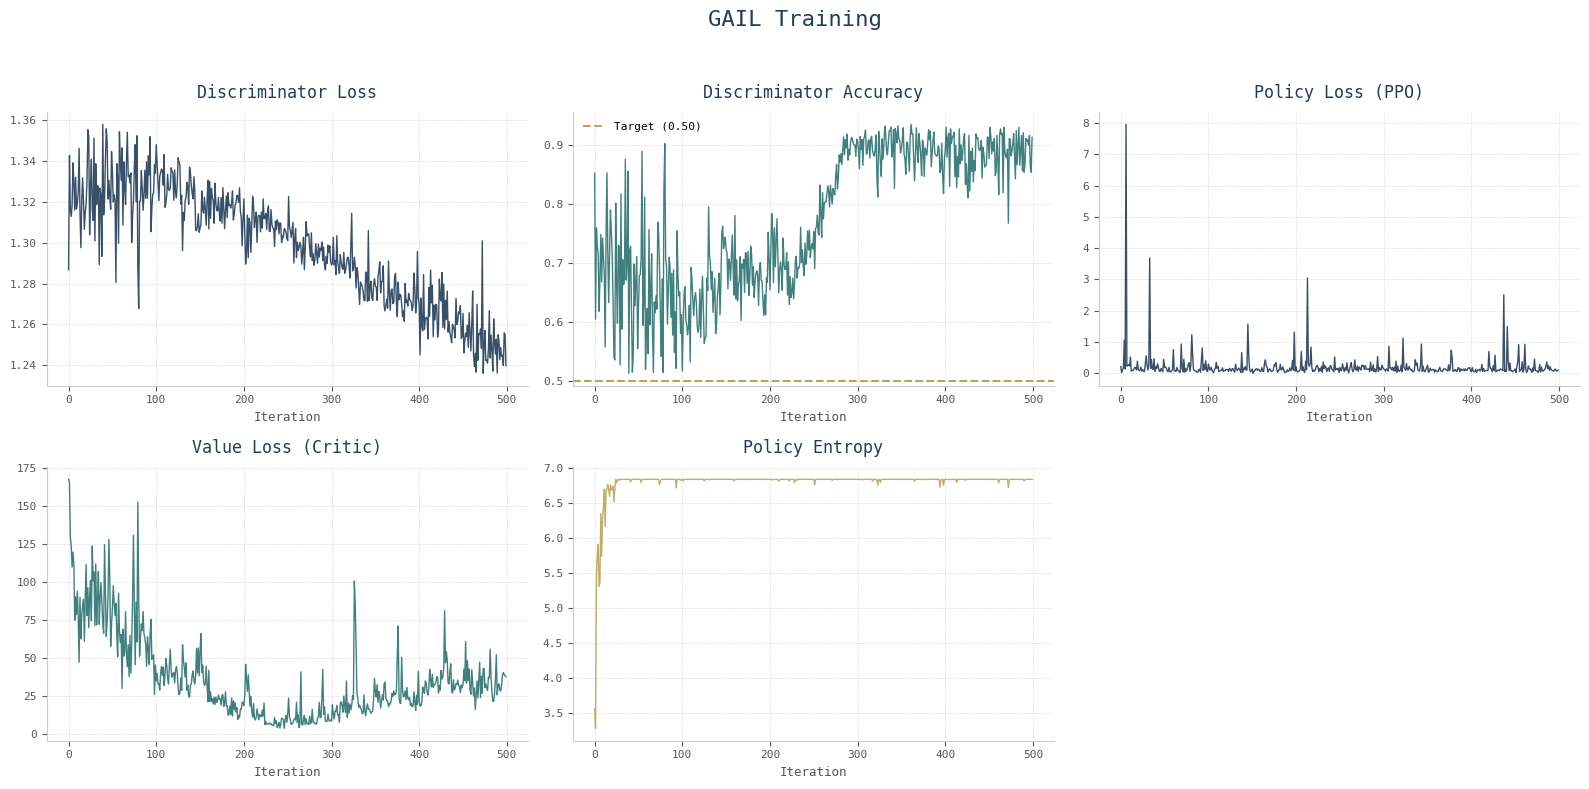

In [14]:
# Set up the matplotlib figure (2 rows, 3 columns)
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("GAIL Training", fontsize=16, color=NAVY, fontweight="normal", y=0.98)

# Flatten axes array for easy iteration
axs = axs.flatten()

# ------------------------ DRAW PLOTS ------------------------
for idx, title, key, color, logic in configPlot:
    ax = axs[idx]
    ax.plot(iterations, data[key], color=color, linewidth=1, alpha=0.9)
    
    # Styling
    ax.set_title(title, fontsize=12, color=NAVY, pad=10)
    ax.set_xlabel("Iteration", fontsize=9, color="#555555")
    ax.tick_params(colors="#555555", labelsize=8)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.7)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#CCCCCC")
    ax.spines['bottom'].set_color("#CCCCCC")

    # Execute extra logic
    if logic:
        logic(ax)
        ax.legend(fontsize=8, frameon=False)

# ------------------------ CLEANUP EMPTY SUBPLOT ------------------------
axs[5].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig(f"{PATH}/gail0{TEST}_results.png", dpi=900)